In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

#import dataset
df = pd.read_csv("train.csv")
df2 = pd.read_csv("test.csv")

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMA model
model = SARIMAX(df['number_sold'], order=(1, 0, 0), seasonal_order=(0, 1, 0, 12))
model_fit = model.fit(disp=False)


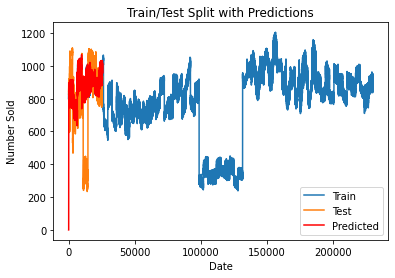

In [3]:
# Forecast the values in the test set
predictions = model_fit.predict(start=df2.index[0], end=df2.index[-1])

# Plot the results
plt.plot(df.index, df['number_sold'], label='Train')
plt.plot(df2.index, df2['number_sold'], label='Test')
plt.plot(predictions.index, predictions, label='Predicted', color='red')
plt.title('Train/Test Split with Predictions')
plt.xlabel('Date')
plt.ylabel('Number Sold')
plt.legend()
plt.show()


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate evaluation metrics
mae = mean_absolute_error(df2['number_sold'], predictions)
rmse = mean_squared_error(df2['number_sold'], predictions, squared=False)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')


MAE: 151.98027761701135
RMSE: 229.56820970817833


/home/laptop-b4u31e4jnot/.pyenv/versions/3.9.5/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
